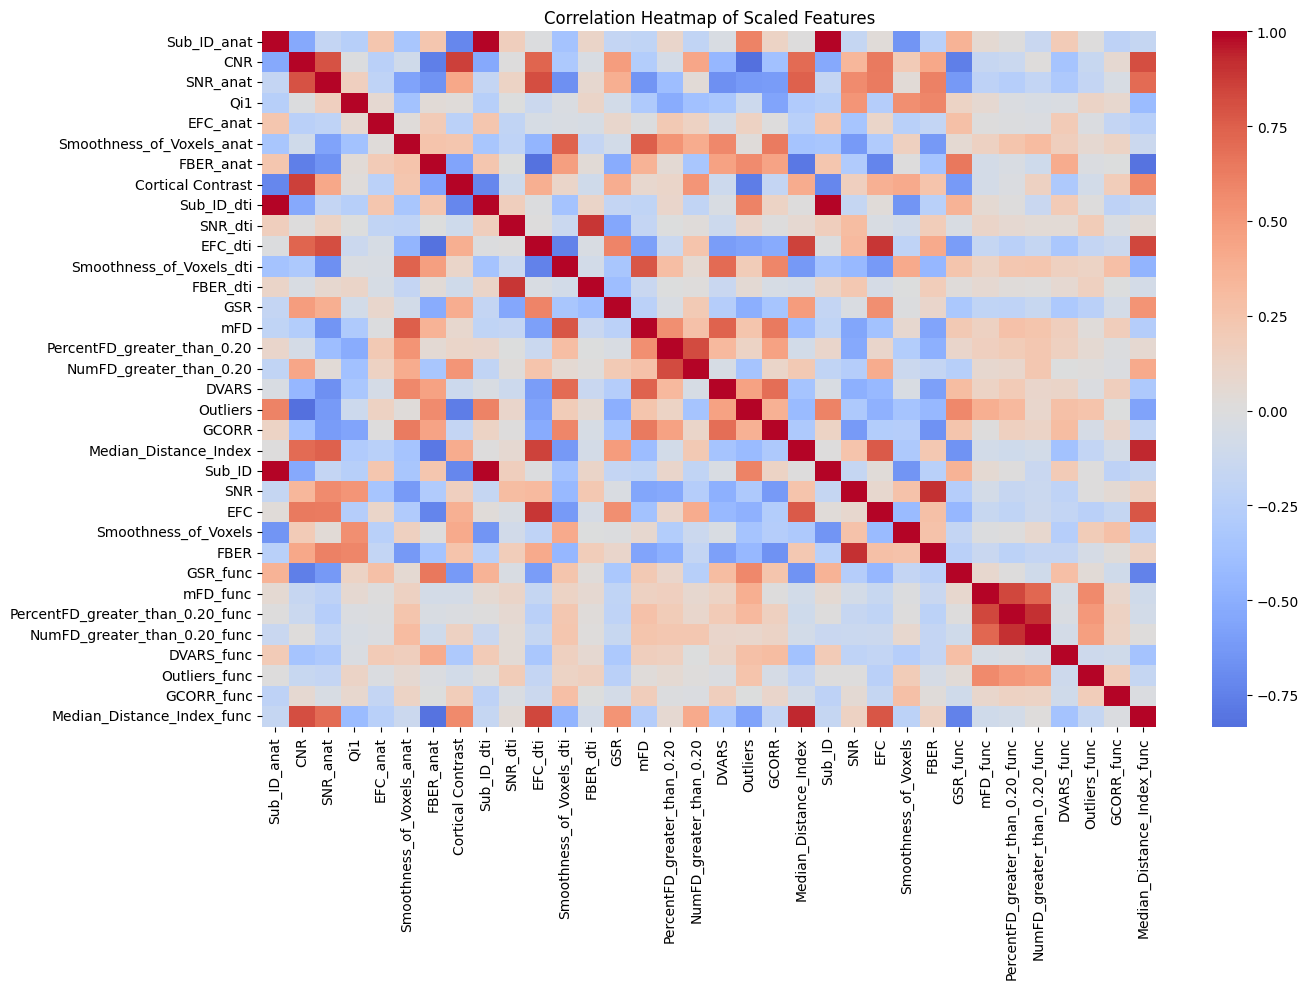

Target variable chosen based on correlation: SNR_anat


In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
anat_df = pd.read_csv('data/anat_qap.csv')
dti_df = pd.read_csv('data/dti_qap.csv')
func_df = pd.read_csv('data/functional_qap.csv')

# Create merge key
def create_merge_key(df):
    return df['Site_ID'].astype(str) + "_" + df['Sub_ID'].astype(str) + "_" + df['Session'].astype(str)

anat_df['merge_key'] = create_merge_key(anat_df)
dti_df['merge_key'] = create_merge_key(dti_df)
func_df['merge_key'] = create_merge_key(func_df)

# Merge datasets
merged_df = anat_df.merge(dti_df, on='merge_key', suffixes=('_anat', '_dti'))
merged_df = merged_df.merge(func_df, on='merge_key', suffixes=('', '_func'))

# Select numeric columns and drop rows with NaNs
numeric_df = merged_df.select_dtypes(include='number').dropna()

# Normalize features
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)

# Find most correlated feature to use as target
target = scaled_data.corr().abs().sum().idxmax()

# Split into features and target
X = scaled_data.drop(columns=[target])
y = scaled_data[target]

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(scaled_data.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Scaled Features")
plt.tight_layout()
plt.show()

print("Target variable chosen based on correlation:", target)






3/3 [==============================] - 0s 2ms/step

--- Dense NN Evaluation ---
R²: 0.9020137215348494
MAE: 0.24524609598192096
RMSE: 0.3286002345602168


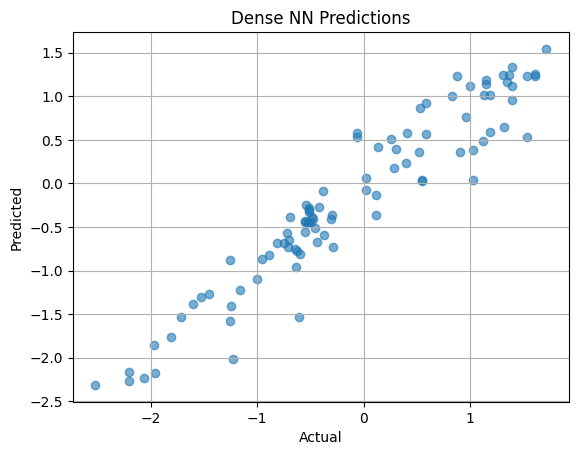


3/3 [==============================] - 0s 3ms/step

--- CNN Evaluation ---
R²: 0.8410170680076473
MAE: 0.3318577800511329
RMSE: 0.418562665916418


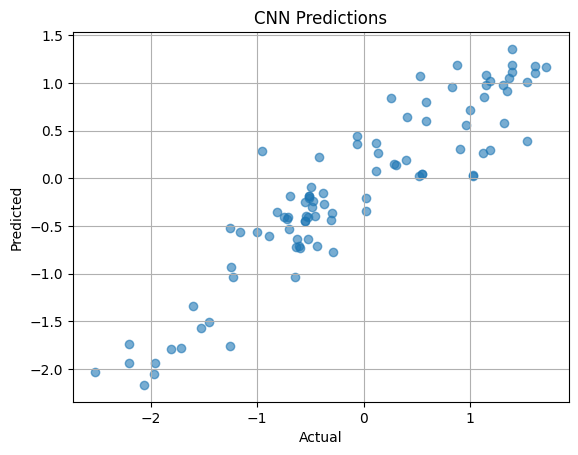

3/3 [==============================] - 0s 52ms/step

--- VGG16 Evaluation ---
R²: -0.014260714138311759
MAE: 0.8971137666457207
RMSE: 1.0572070229031247


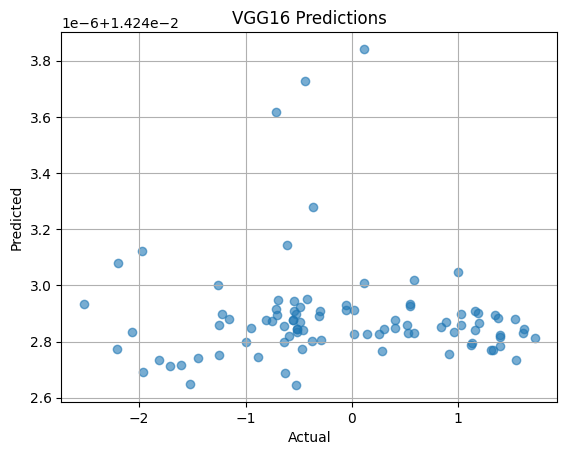

3/3 [==============================] - 1s 48ms/step

--- ResNet50 Evaluation ---
R²: -0.1043154762869074
MAE: 0.92561123486297
RMSE: 1.1031430080629872


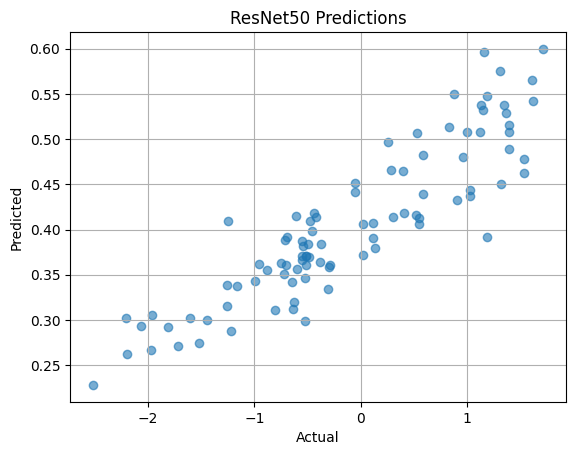

3/3 [==============================] - 0s 2ms/step

--- Transformer Evaluation ---
R²: -0.014897985779533274
MAE: 0.8974414435308712
RMSE: 1.0575390983994313


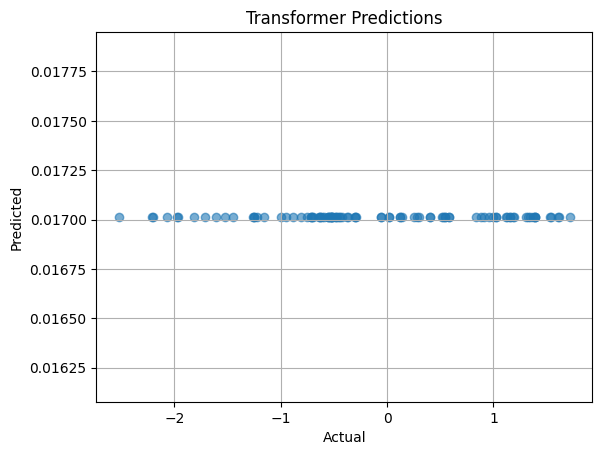

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model

# === 1. Load & Merge Data === #
def create_merge_key(df):
    return df['Site_ID'].astype(str) + "_" + df['Sub_ID'].astype(str) + "_" + df['Session'].astype(str)

anat_df = pd.read_csv('data/anat_qap.csv')
dti_df = pd.read_csv('data/dti_qap.csv')
func_df = pd.read_csv('data/functional_qap.csv')

anat_df['merge_key'] = create_merge_key(anat_df)
dti_df['merge_key'] = create_merge_key(dti_df)
func_df['merge_key'] = create_merge_key(func_df)

merged_df = anat_df.merge(dti_df, on='merge_key', suffixes=('_anat', '_dti'))
merged_df = merged_df.merge(func_df, on='merge_key', suffixes=('', '_func'))

# === 2. Preprocessing === #
numeric_df = merged_df.select_dtypes(include='number').dropna()
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)

target = scaled_data.corr().abs().sum().idxmax()
X = scaled_data.drop(columns=[target])
y = scaled_data[target]

# Reshape for image-like input: 6x6 (if len(X.columns) = 36)
feature_count = X.shape[1]
side = int(np.ceil(np.sqrt(feature_count)))
padded = X.copy()

# Pad if not square
for i in range(side**2 - feature_count):
    padded[f'pad_{i}'] = 0

X_img = padded.values.reshape(-1, side, side, 1)
X_train, X_test, y_train, y_test = train_test_split(X_img, y, test_size=0.2, random_state=42)

# === 3. Build Models === #

def build_dense_model(input_shape):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    return model

def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(1)
    ])
    return model

def build_pretrained_model(base_model_fn, input_shape):
    input_layer = layers.Input(shape=input_shape)
    x = layers.Conv2D(3, (1, 1))(input_layer)  # Convert 1-channel to 3-channel
    x = layers.Resizing(32, 32)(x)  # Resize to standard input for VGG/ResNet
    base_model = base_model_fn(include_top=False, input_tensor=x, weights=None, input_shape=(32, 32, 3))
    x = layers.GlobalAveragePooling2D()(base_model.output)
    output = layers.Dense(1)(x)
    return Model(inputs=input_layer, outputs=output)

# === 4. Training Function === #
def compile_and_train(model, name):
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

    preds = model.predict(X_test).flatten()
    print(f"\n--- {name} Evaluation ---")
    print("R²:", r2_score(y_test, preds))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

    # Plot
    plt.figure()
    plt.scatter(y_test, preds, alpha=0.6)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name} Predictions")
    plt.grid(True)
    plt.show()

# === 5. Train All Models === #

# Dense Neural Network
dnn_model = build_dense_model((side, side, 1))
compile_and_train(dnn_model, "Dense NN")

# CNN
cnn_model = build_cnn_model((side, side, 1))
compile_and_train(cnn_model, "CNN")

# VGG16
vgg_model = build_pretrained_model(VGG16, (side, side, 1))
compile_and_train(vgg_model, "VGG16")

# ResNet50
resnet_model = build_pretrained_model(ResNet50, (side, side, 1))
compile_and_train(resnet_model, "ResNet50")

# === Optional: Simple Transformer === #
try:
    from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dense, Flatten

    def build_transformer(input_shape):
        inputs = layers.Input(shape=input_shape)
        x = layers.Reshape((input_shape[0]*input_shape[1], 1))(inputs)
        attn_output = MultiHeadAttention(num_heads=2, key_dim=2)(x, x)
        x = LayerNormalization()(x + attn_output)
        x = Flatten()(x)
        x = Dense(64, activation='relu')(x)
        output = Dense(1)(x)
        return Model(inputs, output)

    transformer_model = build_transformer((side, side, 1))
    compile_and_train(transformer_model, "Transformer")

except ImportError:
    print("Transformer layers require TensorFlow 2.4+ with attention layers.")
